# Heart Disease Risk Predictor

# Exploratory Data Analysis (EDA)

## Objective
This notebook explores the cleaned heart disease dataset to understand patient characteristics, identify relationships between clinical features and heart disease, and generate insights that support machine learning model development.

The analysis includes:
- Dataset overview
- Target distribution
- Numerical feature analysis
- Categorical feature analysis
- Feature relationship analysis
- Correlation analysis
- Key findings

In [103]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook"
)

pd.set_option("display.max_columns", None)
PRIMARY_COLOR = "#4C72B0"
FIGSIZE = (8,5)
BOX_FIGSIZE = (8,2.5)
DPI = 300

In [105]:
PROJECT_ROOT = Path("..")
EDA_IMAGE_DIR = PROJECT_ROOT / "images" / "eda"
EDA_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [106]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        EDA_IMAGE_DIR / f"{filename}.png",
        dpi=DPI,
        bbox_inches="tight"
    )

    print(f"✓ Saved : {filename}.png")

In [107]:
df = pd.read_csv("../data/processed/heart_disease_clean.csv")

# Dataset Overview
Before performing exploratory analysis, the cleaned dataset is briefly inspected to verify its structure and ensure it is ready for visualization.

In [108]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (303, 14)


In [109]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [111]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


# Target Variable Distribution
Understanding the class distribution is important before developing a classification model.
A balanced dataset generally enables machine learning algorithms to learn both classes effectively.

✓ Saved : target_distribution.png


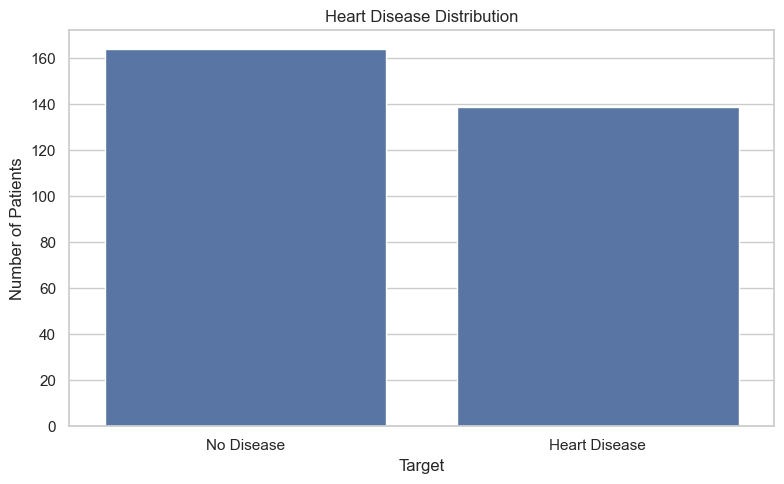

In [112]:
plt.figure(figsize=FIGSIZE)

sns.countplot(
    data=df,
    x="target",
    color=PRIMARY_COLOR
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["No Disease","Heart Disease"])
save_plot("target_distribution")
plt.show()

In [113]:
target_distribution = (df["target"].value_counts().rename({
        0:"No Disease",
        1:"Heart Disease"
    })
)

target_distribution

target
No Disease       164
Heart Disease    139
Name: count, dtype: int64

In [114]:
(df["target"].value_counts(normalize=True).rename({
        0:"No Disease",
        1:"Heart Disease"
    }).mul(100).round(2)
)

target
No Disease       54.13
Heart Disease    45.87
Name: proportion, dtype: float64

### Insights
- Observe whether the dataset is balanced between patients with and without heart disease.
- Identify potential class imbalance.
- Determine whether resampling techniques may be required during model development.

# Feature Classification
The dataset consists of numerical and categorical variables.
Separating these feature types allows each variable to be analyzed using the most appropriate visualization techniques.

In [115]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [116]:
print("Numerical Features")
print(numerical_features)
print()
print("Categorical Features")
print(categorical_features)

Numerical Features
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


# Exploratory Analysis Roadmap
The remaining sections of this notebook will analyze each feature individually before examining relationships between features and the target variable.
This approach helps generate meaningful insights while maintaining a structured analytical workflow.

# Age Analysis
The `age` feature represents the patient's age in years.
Age is one of the most important demographic factors associated with cardiovascular disease. This section explores the age distribution, identifies potential outliers, and summarizes its statistical characteristics.

✓ Saved : age_distribution.png


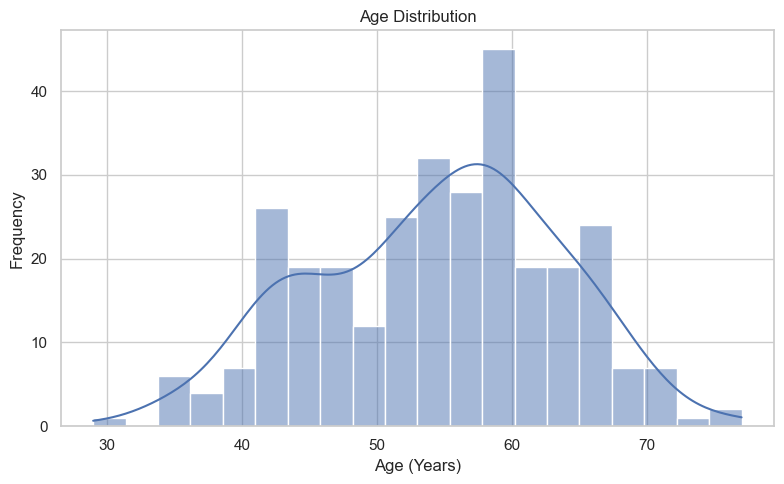

In [117]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    data=df,
    x="age",
    kde=True,
    bins=20,
    color=PRIMARY_COLOR
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
save_plot("age_distribution")
plt.show()

✓ Saved : age_boxplot.png


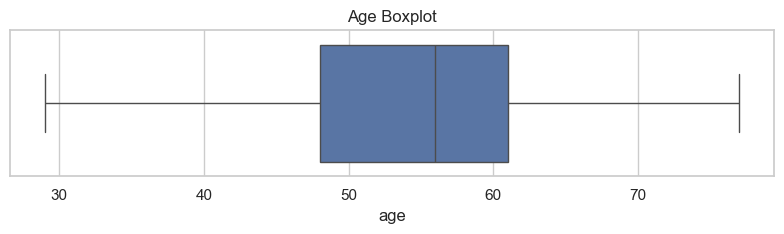

In [118]:
plt.figure(figsize=BOX_FIGSIZE)

sns.boxplot(
    data=df,
    x="age",
    color=PRIMARY_COLOR
)

plt.title("Age Boxplot")
save_plot("age_boxplot")
plt.show()

In [119]:
df["age"].describe().to_frame().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0


### Insights
- Identify the dominant age range of the patients.
- Observe whether the age distribution is approximately normal.
- Detect the presence of potential outliers.
- Evaluate whether age may influence heart disease risk.

# Resting Blood Pressure Analysis
The `trestbps` feature represents the patient's resting systolic blood pressure measured before exercise testing.
Blood pressure is one of the major clinical indicators used to assess cardiovascular health.

✓ Saved : trestbps_distribution.png


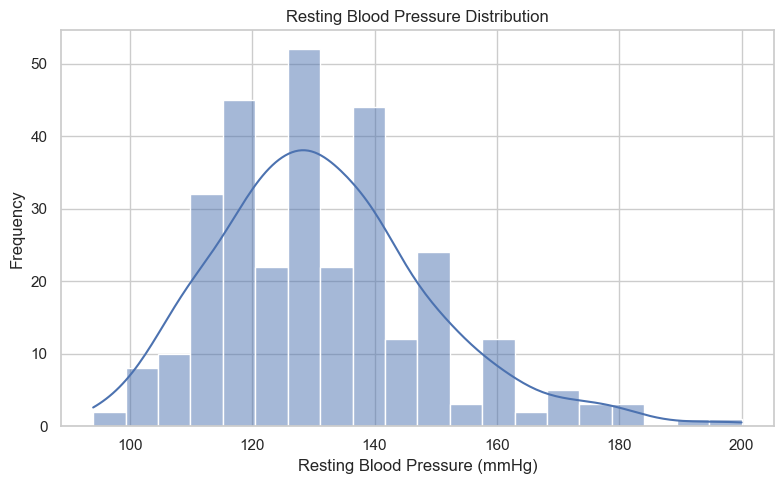

In [120]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    data=df,
    x="trestbps",
    kde=True,
    bins=20,
    color=PRIMARY_COLOR
)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.ylabel("Frequency")
save_plot("trestbps_distribution")
plt.show()

✓ Saved : trestbps_boxplot.png


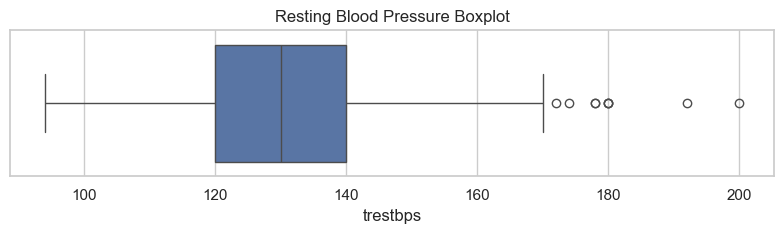

In [121]:
plt.figure(figsize=BOX_FIGSIZE)

sns.boxplot(
    data=df,
    x="trestbps",
    color=PRIMARY_COLOR
)

plt.title("Resting Blood Pressure Boxplot")
save_plot("trestbps_boxplot")
plt.show()

In [122]:
df["trestbps"].describe().to_frame().T.round(2)

,count,mean,std,min,25%,50%,75%,max
trestbps,303.0,131.69,17.6,94.0,120.0,130.0,140.0,200.0


### Insights
- Observe the concentration of resting blood pressure values.
- Identify potential hypertension-related outliers.
- Assess the overall variability of blood pressure among patients.
- Evaluate whether further preprocessing is required.

# Serum Cholesterol Analysis
The `chol` feature represents the patient's total serum cholesterol level measured in **mg/dL**.
Elevated cholesterol contributes to plaque formation inside coronary arteries and increases the risk of cardiovascular disease.

✓ Saved : chol_distribution.png


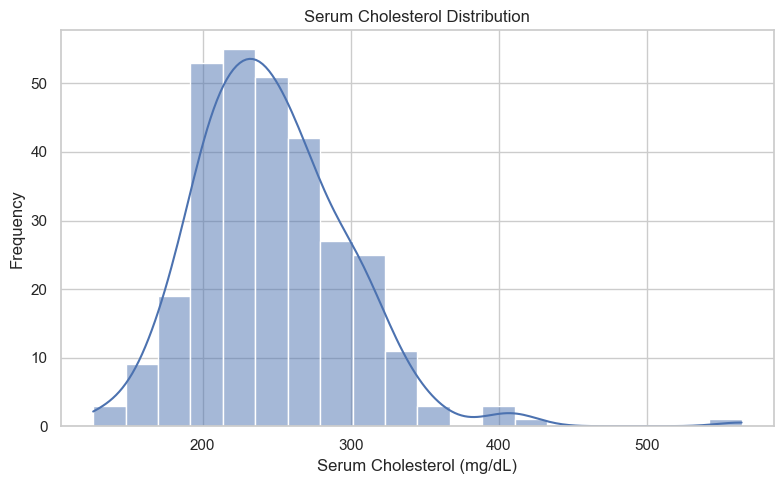

In [123]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    data=df,
    x="chol",
    kde=True,
    bins=20,
    color=PRIMARY_COLOR
)

plt.title("Serum Cholesterol Distribution")
plt.xlabel("Serum Cholesterol (mg/dL)")
plt.ylabel("Frequency")
save_plot("chol_distribution")
plt.show()

✓ Saved : chol_boxplot.png


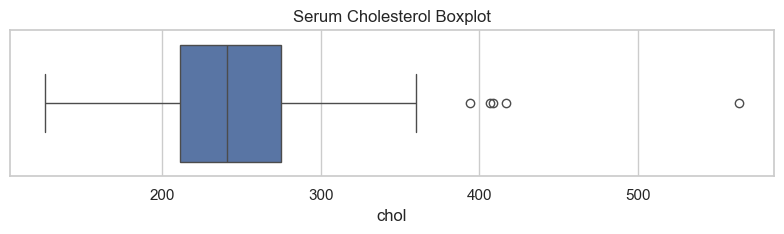

In [124]:
plt.figure(figsize=BOX_FIGSIZE)

sns.boxplot(
    data=df,
    x="chol",
    color=PRIMARY_COLOR
)

plt.title("Serum Cholesterol Boxplot")
save_plot("chol_boxplot")
plt.show()

In [125]:
df["chol"].describe().to_frame().T.round(2)

,count,mean,std,min,25%,50%,75%,max
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0


### Insights
- Observe the overall cholesterol distribution.
- Detect extreme cholesterol values.
- Evaluate whether the feature is positively skewed.
- Consider whether outlier treatment is necessary before model training.

# Maximum Heart Rate Analysis
The `thalach` feature represents the maximum heart rate achieved during exercise testing.
Maximum heart rate reflects the patient's cardiovascular response to physical activity and is commonly used to assess heart function.

✓ Saved : thalach_distribution.png


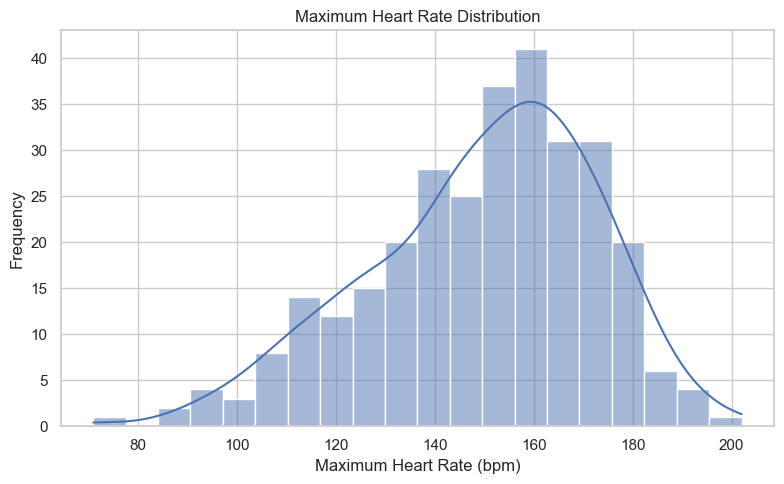

In [126]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    data=df,
    x="thalach",
    kde=True,
    bins=20,
    color=PRIMARY_COLOR
)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Frequency")
save_plot("thalach_distribution")
plt.show()

✓ Saved : thalach_boxplot.png


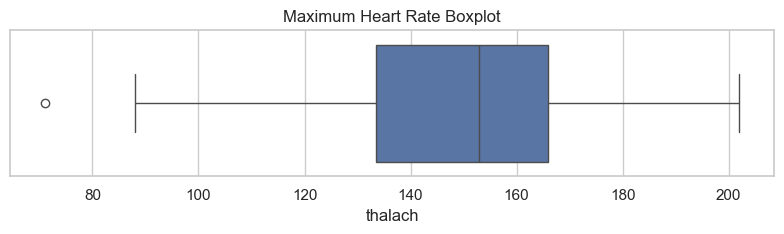

In [127]:
plt.figure(figsize=BOX_FIGSIZE)

sns.boxplot(
    data=df,
    x="thalach",
    color=PRIMARY_COLOR
)

plt.title("Maximum Heart Rate Boxplot")
save_plot("thalach_boxplot")
plt.show()

In [128]:
df["thalach"].describe().to_frame().T.round(2)

,count,mean,std,min,25%,50%,75%,max
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0


### Insights
- Observe the distribution of maximum heart rate values.
- Identify unusually low or high observations.
- Assess the variability of patient heart rate responses.
- Determine whether the feature contains potential outliers.

# Oldpeak Analysis
The `oldpeak` feature measures ST depression induced by exercise relative to rest.
Higher Oldpeak values generally indicate a greater degree of myocardial ischemia, making this feature clinically important for heart disease assessment.

✓ Saved : oldpeak_distribution.png


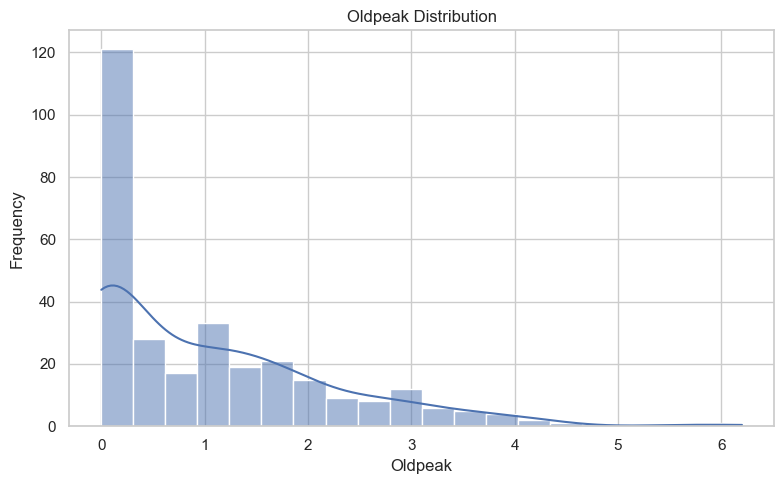

In [129]:
plt.figure(figsize=FIGSIZE)

sns.histplot(
    data=df,
    x="oldpeak",
    kde=True,
    bins=20,
    color=PRIMARY_COLOR
)

plt.title("Oldpeak Distribution")
plt.xlabel("Oldpeak")
plt.ylabel("Frequency")
save_plot("oldpeak_distribution")
plt.show()

✓ Saved : oldpeak_boxplot.png


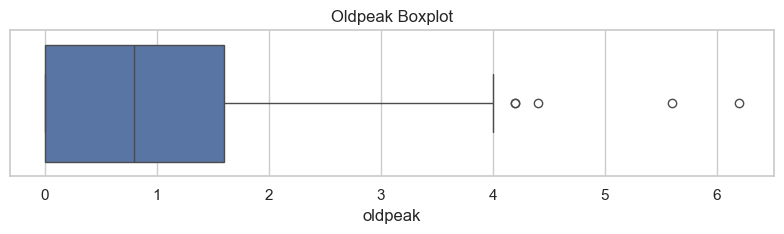

In [130]:
plt.figure(figsize=BOX_FIGSIZE)

sns.boxplot(
    data=df,
    x="oldpeak",
    color=PRIMARY_COLOR
)

plt.title("Oldpeak Boxplot")
save_plot("oldpeak_boxplot")
plt.show()

In [131]:
df["oldpeak"].describe().to_frame().T.round(2)

,count,mean,std,min,25%,50%,75%,max
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


### Insights
- Observe whether Oldpeak values are concentrated near zero.
- Detect patients with unusually high ST depression.
- Assess the overall distribution shape.
- Evaluate whether feature scaling should be considered before model development.

# Sex Analysis
The `sex` feature represents the biological sex of each patient.
This analysis examines the gender distribution within the dataset and evaluates whether one gender is more prevalent than the other.

✓ Saved : sex_distribution.png


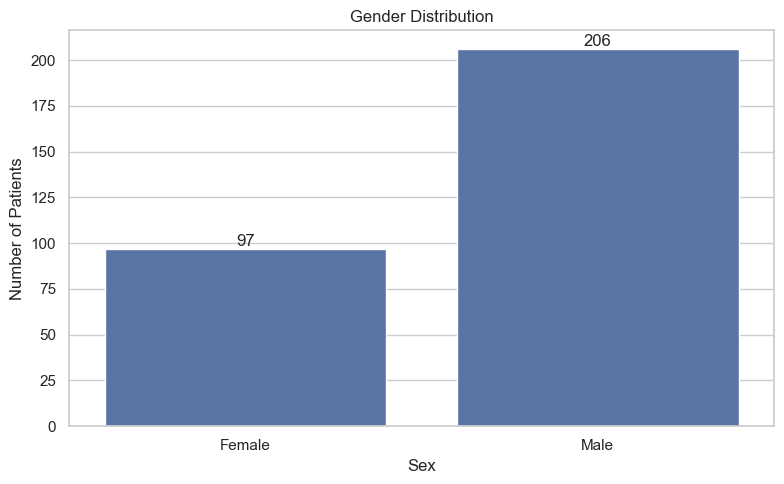

In [132]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="sex",
    color=PRIMARY_COLOR
)

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["Female","Male"])

for container in ax.containers:
    ax.bar_label(container)

save_plot("sex_distribution")
plt.show()

In [133]:
df["sex"].value_counts().rename({
    0:"Female",
    1:"Male"
})

sex
Male      206
Female     97
Name: count, dtype: int64

In [134]:
(df["sex"].value_counts(normalize=True).rename({
        0:"Female",
        1:"Male"
    }).mul(100).round(2)
)

sex
Male      67.99
Female    32.01
Name: proportion, dtype: float64

### Insights
- Identify the dominant gender in the dataset.
- Observe whether the patient population is balanced.
- Consider whether gender imbalance could influence model learning.

# Chest Pain Type Analysis
The `cp` feature describes the type of chest pain experienced by each patient.
Chest pain characteristics are among the most important clinical indicators used in diagnosing heart disease.

✓ Saved : cp_distribution.png


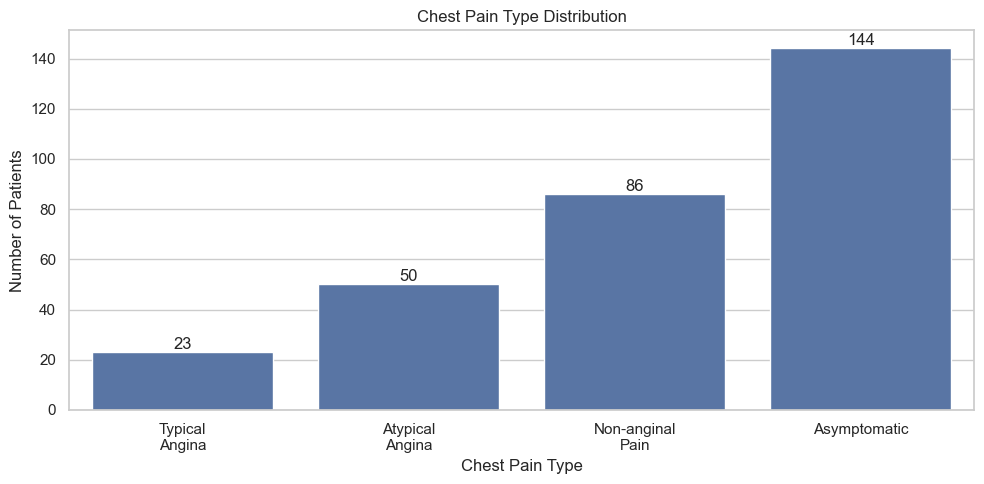

In [135]:
cp_labels = {
    1: "Typical\nAngina",
    2: "Atypical\nAngina",
    3: "Non-anginal\nPain",
    4: "Asymptomatic"
}

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="cp",
    color=PRIMARY_COLOR,
    order=sorted(df["cp"].unique())
)

plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2,3],
    labels=list(cp_labels.values())
)

for container in ax.containers:
    ax.bar_label(container)

save_plot("cp_distribution")
plt.show()

In [136]:
(df["cp"].value_counts().sort_index())

cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

In [137]:
(df["cp"].value_counts(normalize=True).sort_index().mul(100).round(2))

cp
1.0     7.59
2.0    16.50
3.0    28.38
4.0    47.52
Name: proportion, dtype: float64

### Insights
- Identify the most common chest pain type.
- Observe whether asymptomatic patients dominate the dataset.
- Evaluate whether chest pain type may become an important predictor for heart disease.

# Fasting Blood Sugar Analysis
The `fbs` feature indicates whether the patient's fasting blood sugar level exceeds **120 mg/dL**.
Elevated fasting blood sugar is commonly associated with diabetes, which is one of the major cardiovascular risk factors.

✓ Saved : fbs_distribution.png


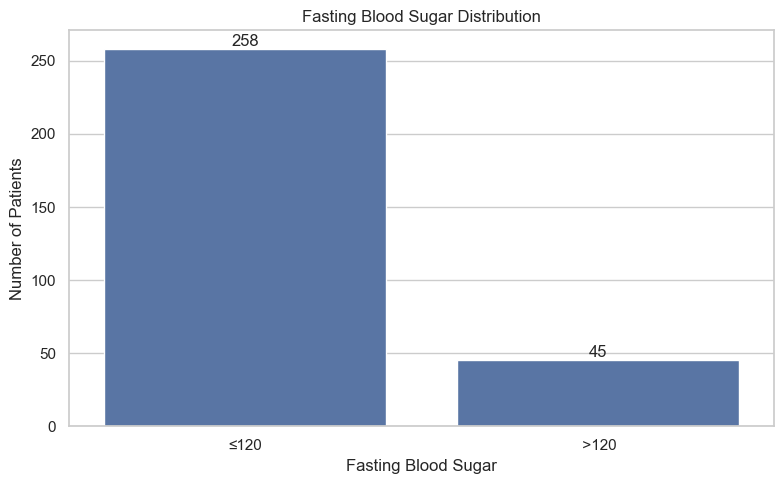

In [138]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="fbs",
    color=PRIMARY_COLOR
)

plt.title("Fasting Blood Sugar Distribution")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["≤120"," >120"])

for container in ax.containers:
    ax.bar_label(container)

save_plot("fbs_distribution")
plt.show()

In [139]:
df["fbs"].value_counts().rename({
    0:"≤120 mg/dL",
    1:">120 mg/dL"
})

fbs
≤120 mg/dL    258
>120 mg/dL     45
Name: count, dtype: int64

In [140]:
(df["fbs"].value_counts(normalize=True)
    .rename({
        0:"≤120 mg/dL",
        1:">120 mg/dL"
    }).mul(100).round(2)
)

fbs
≤120 mg/dL    85.15
>120 mg/dL    14.85
Name: proportion, dtype: float64

### Insights
- Observe the proportion of patients with elevated fasting blood sugar.
- Determine whether high blood sugar is common within the dataset.
- Consider its potential contribution to heart disease prediction.

# Resting Electrocardiographic Results Analysis
The `restecg` feature represents the patient's resting electrocardiogram (ECG) result.
ECG abnormalities may indicate structural or electrical abnormalities of the heart.

✓ Saved : restecg_distribution.png


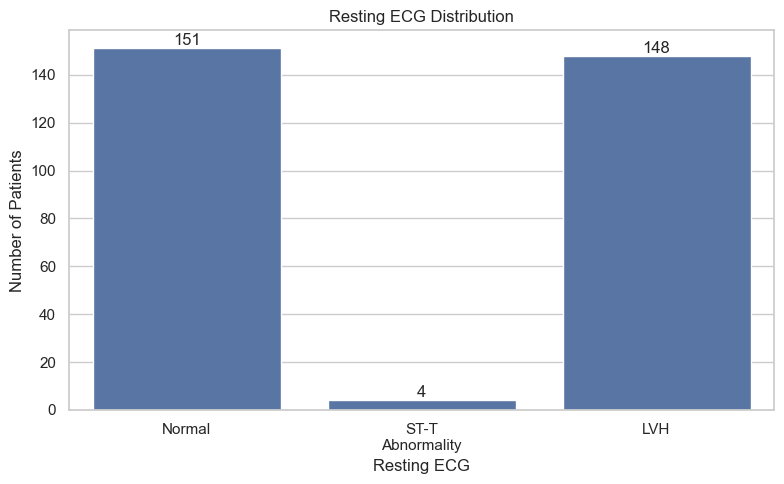

In [141]:
restecg_labels = {
    0:"Normal",
    1:"ST-T\nAbnormality",
    2:"LVH"
}

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="restecg",
    color=PRIMARY_COLOR,
    order=sorted(df["restecg"].unique())
)

plt.title("Resting ECG Distribution")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2],
    labels=list(restecg_labels.values())
)

for container in ax.containers:
    ax.bar_label(container)

save_plot("restecg_distribution")
plt.show()

In [142]:
(df["restecg"].value_counts().sort_index())

restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

In [143]:
(df["restecg"].value_counts(normalize=True).sort_index().mul(100).round(2))

restecg
0.0    49.83
1.0     1.32
2.0    48.84
Name: proportion, dtype: float64

### Insights
- Identify the most common ECG result.
- Observe the prevalence of ECG abnormalities among patients.
- Consider whether abnormal ECG findings may contribute to heart disease prediction.

# Exercise Induced Angina Analysis
The `exang` feature indicates whether the patient experienced chest pain during physical exercise.
Exercise-induced angina may indicate insufficient blood flow to the heart when oxygen demand increases, making it an important clinical indicator of coronary artery disease.

✓ Saved : exang_distribution.png


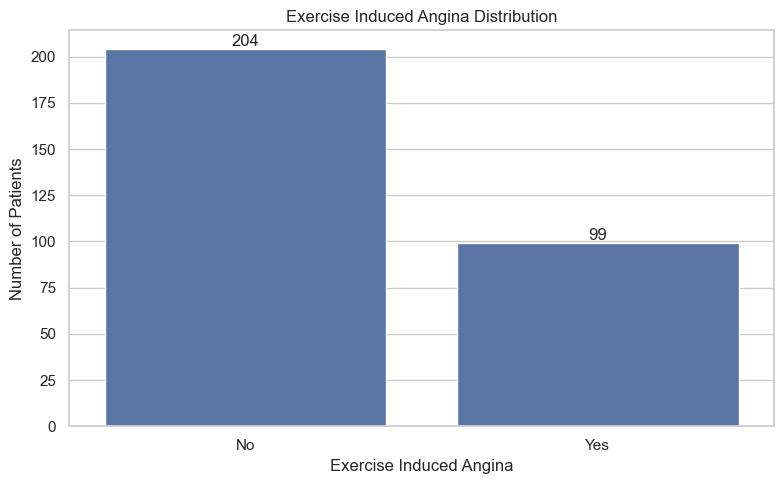

In [144]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="exang",
    color=PRIMARY_COLOR
)

plt.title("Exercise Induced Angina Distribution")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No","Yes"])

for container in ax.containers:
    ax.bar_label(container)

save_plot("exang_distribution")
plt.show()

In [145]:
df["exang"].value_counts().rename({
    0:"No",
    1:"Yes"
})

exang
No     204
Yes     99
Name: count, dtype: int64

In [146]:
(df["exang"].value_counts(normalize=True).rename({
        0:"No",
        1:"Yes"
    }).mul(100).round(2)
)

exang
No     67.33
Yes    32.67
Name: proportion, dtype: float64

### Insights
- Observe the proportion of patients experiencing exercise-induced angina.
- Determine whether this condition is common within the dataset.
- Consider its potential importance in heart disease prediction.

# ST Slope Analysis
The `slope` feature describes the slope of the ST segment during peak exercise.
Changes in the ST segment are commonly evaluated during stress testing and may indicate abnormalities in blood flow to the heart.

✓ Saved : slope_distribution.png


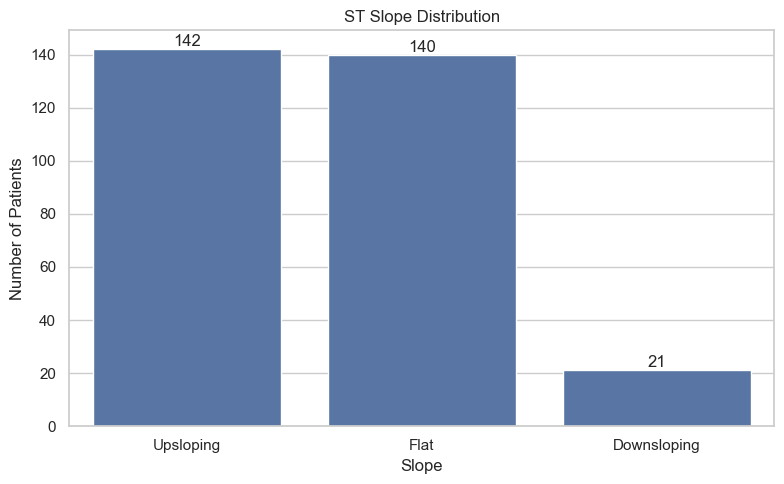

In [147]:
slope_labels = {
    1:"Upsloping",
    2:"Flat",
    3:"Downsloping"
}

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="slope",
    color=PRIMARY_COLOR,
    order=sorted(df["slope"].unique())
)

plt.title("ST Slope Distribution")
plt.xlabel("Slope")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2],
    labels=list(slope_labels.values())
)

for container in ax.containers:
    ax.bar_label(container)

save_plot("slope_distribution")
plt.show()

In [148]:
(df["slope"].value_counts().sort_index())

slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

In [149]:
(df["slope"].value_counts(normalize=True).sort_index().mul(100).round(2))

slope
1.0    46.86
2.0    46.20
3.0     6.93
Name: proportion, dtype: float64

### Insights
- Identify the most common ST slope category.
- Observe whether abnormal slope patterns are frequent.
- Consider the clinical significance of ST slope in heart disease assessment.

# Number of Major Vessels Analysis
The `ca` feature represents the number of major coronary vessels visualized during fluoroscopy.
This feature provides information about coronary artery condition and is often considered an important predictor of heart disease.

✓ Saved : ca_distribution.png


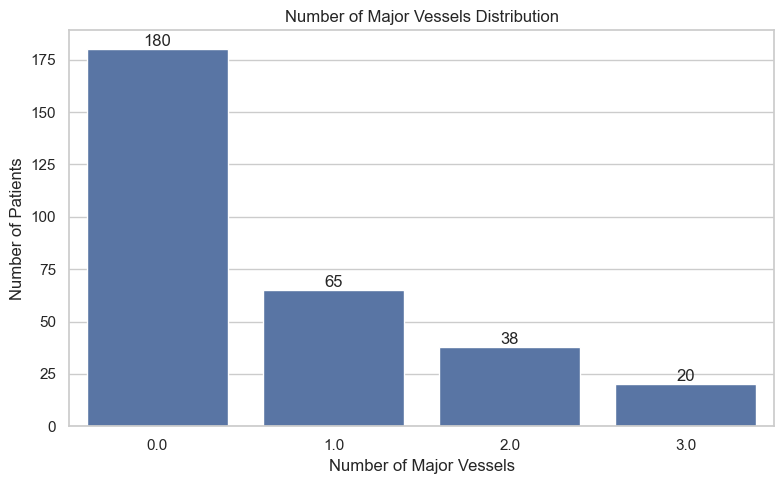

In [150]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="ca",
    order=sorted(df["ca"].unique()),
    color=PRIMARY_COLOR
)

plt.title("Number of Major Vessels Distribution")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")

ax.bar_label(ax.containers[0])
save_plot("ca_distribution")
plt.show()

In [151]:
(df["ca"].value_counts().sort_index())

ca
0.0    180
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [152]:
(df["ca"].value_counts(normalize=True).sort_index().mul(100).round(2))

ca
0.0    59.41
1.0    21.45
2.0    12.54
3.0     6.60
Name: proportion, dtype: float64

### Insights
- Observe the distribution of major coronary vessels.
- Identify the most common category.
- Evaluate whether higher vessel counts are relatively uncommon.

# Thallium Stress Test Analysis
The `thal` feature represents the result of the Thallium Stress Test.
This examination evaluates blood flow to the heart muscle and helps identify permanent or reversible perfusion defects.

✓ Saved : thal_distribution.png


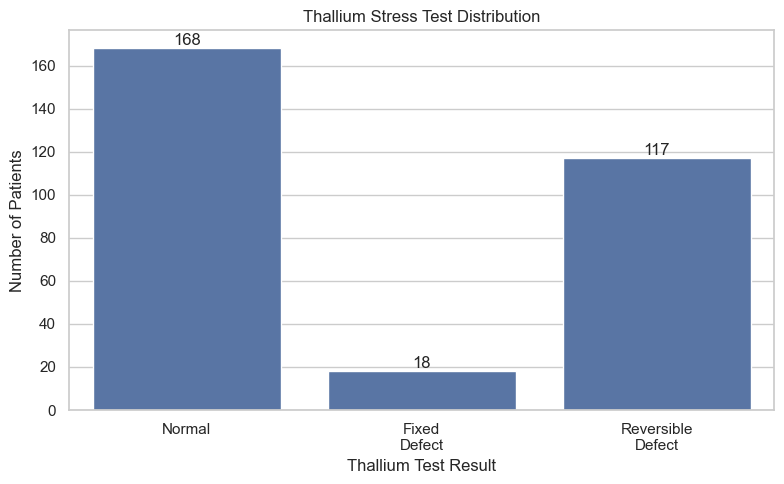

In [153]:
thal_labels = {
    3:"Normal",
    6:"Fixed\nDefect",
    7:"Reversible\nDefect"
}

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="thal",
    color=PRIMARY_COLOR,
    order=sorted(df["thal"].unique())
)

plt.title("Thallium Stress Test Distribution")
plt.xlabel("Thallium Test Result")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2],
    labels=list(thal_labels.values())
)

for container in ax.containers:
    ax.bar_label(container)

save_plot("thal_distribution")
plt.show()

In [154]:
(df["thal"].value_counts().sort_index())

thal
3.0    168
6.0     18
7.0    117
Name: count, dtype: int64

In [155]:
(df["thal"].value_counts(normalize=True).sort_index().mul(100).round(2))

thal
3.0    55.45
6.0     5.94
7.0    38.61
Name: proportion, dtype: float64

### Insights
- Identify the most common Thallium Stress Test result.
- Observe the proportion of patients with abnormal findings.
- Consider the clinical importance of this feature in heart disease prediction.

# Feature vs Target Analysis
After understanding each feature individually, the next step is to examine how each feature relates to the target variable.
This analysis helps identify which clinical characteristics differ between patients with and without heart disease, providing valuable insights before machine learning model development.

# Age vs Heart Disease
This analysis compares the age distribution between patients diagnosed with heart disease and those without heart disease.

✓ Saved : age_vs_target.png


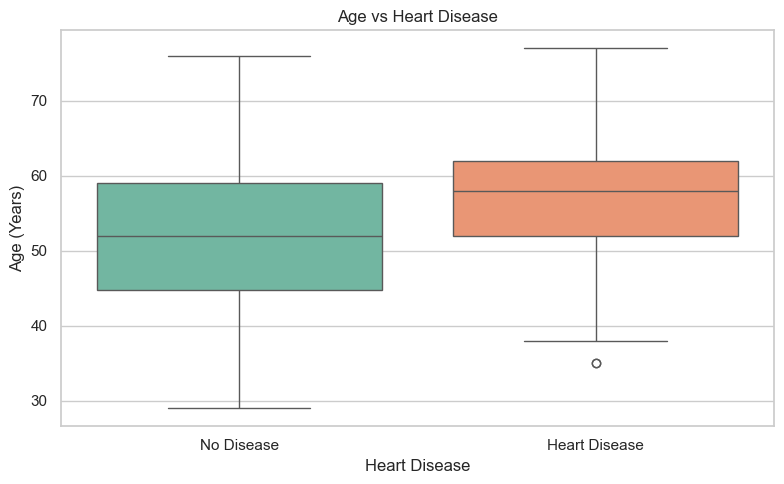

In [156]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="target",
    y="age",
    palette="Set2"
)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age (Years)")
plt.xticks([0,1], ["No Disease","Heart Disease"])
save_plot("age_vs_target")
plt.show()

In [157]:
df.groupby("target")["age"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,52.59,9.51,29.0,44.75,52.0,59.0,76.0
1,139.0,56.63,7.94,35.0,52.00,58.0,62.0,77.0


### Insights
- Compare the age distribution between the two target classes.
- Observe whether patients with heart disease tend to be older.
- Identify potential age differences that may influence prediction.

# Resting Blood Pressure vs Heart Disease
This analysis compares resting blood pressure between patients with and without heart disease.

✓ Saved : trestbps_vs_target.png


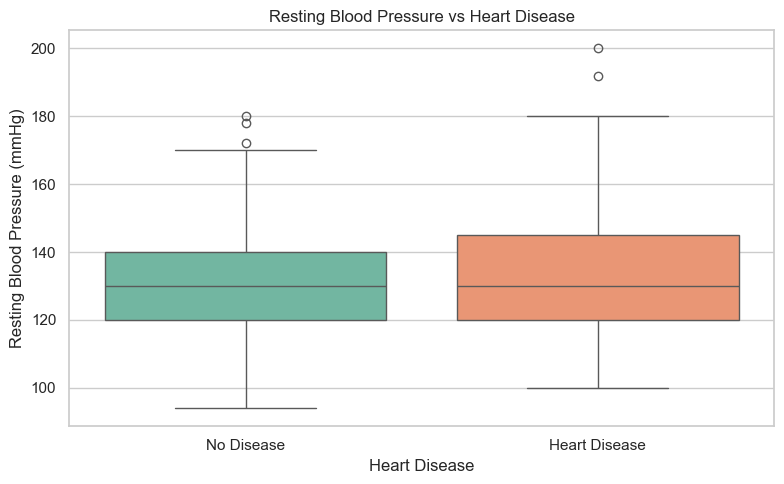

In [158]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="target",
    y="trestbps",
    palette="Set2"
)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Resting Blood Pressure (mmHg)")
plt.xticks([0,1], ["No Disease","Heart Disease"])
save_plot("trestbps_vs_target")
plt.show()

In [159]:
df.groupby("target")["trestbps"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,129.25,16.20,94.0,120.0,130.0,140.0,180.0
1,139.0,134.57,18.77,100.0,120.0,130.0,145.0,200.0


### Insights
- Compare resting blood pressure between the two groups.
- Observe differences in median and variability.
- Identify potential outliers.

# Serum Cholesterol vs Heart Disease
This section compares serum cholesterol levels between patients diagnosed with and without heart disease.

✓ Saved : chol_vs_target.png


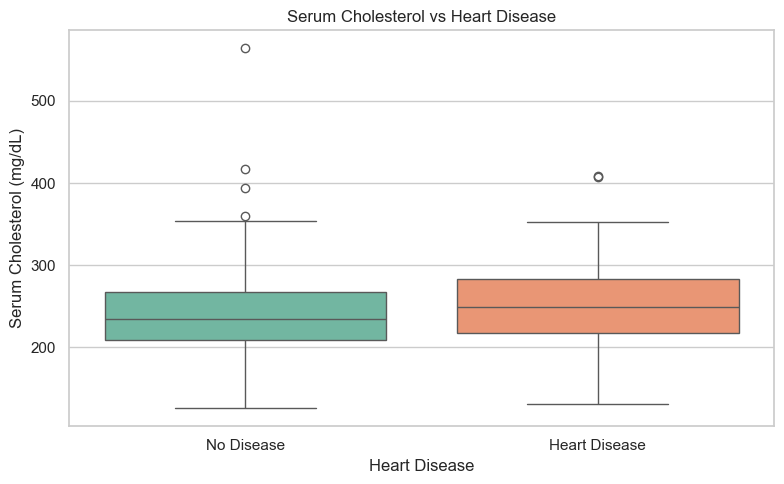

In [160]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="target",
    y="chol",
    palette="Set2"
)

plt.title("Serum Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.xticks([0,1], ["No Disease","Heart Disease"])
save_plot("chol_vs_target")
plt.show()

In [161]:
df.groupby("target")["chol"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,242.64,53.46,126.0,208.75,234.5,267.25,564.0
1,139.0,251.47,49.49,131.0,217.50,249.0,283.50,409.0


### Insights
- Compare cholesterol levels between both patient groups.
- Observe differences in median values.
- Identify the presence of extreme observations.

# Maximum Heart Rate vs Heart Disease
This section compares the maximum heart rate achieved between patients with and without heart disease.

✓ Saved : thalach_vs_target.png


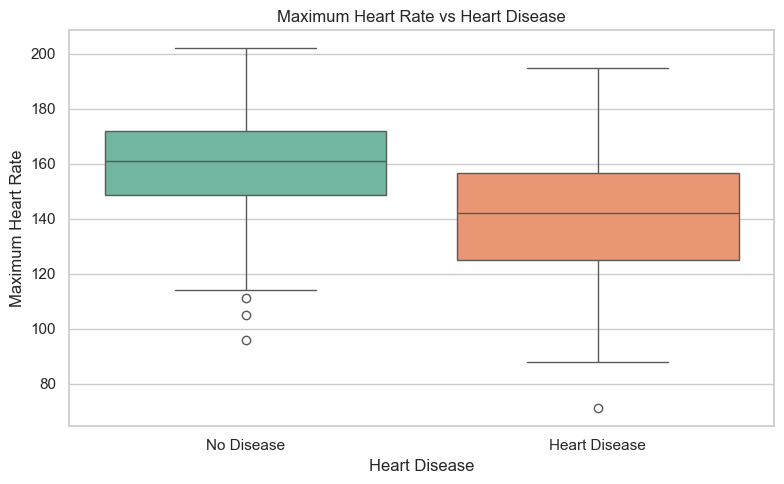

In [162]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="target",
    y="thalach",
    palette="Set2"
)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.xticks([0,1], ["No Disease","Heart Disease"])
save_plot("thalach_vs_target")
plt.show()

In [163]:
df.groupby("target")["thalach"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,158.38,19.20,96.0,148.75,161.0,172.0,202.0
1,139.0,139.26,22.59,71.0,125.00,142.0,156.5,195.0


### Insights
- Compare maximum heart rate between the two target classes.
- Observe differences in central tendency.
- Evaluate whether reduced heart rate is associated with heart disease.

# Oldpeak vs Heart Disease
Oldpeak is one of the strongest clinical indicators related to myocardial ischemia.
This section compares Oldpeak values between patients with and without heart disease.

✓ Saved : oldpeak_vs_target.png


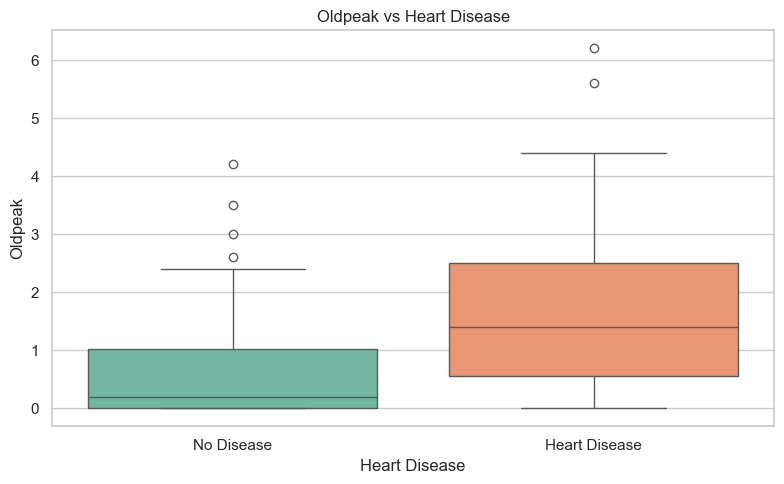

In [164]:
plt.figure(figsize=FIGSIZE)

sns.boxplot(
    data=df,
    x="target",
    y="oldpeak",
    palette="Set2"
)

plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")
plt.xticks([0,1], ["No Disease","Heart Disease"])
save_plot("oldpeak_vs_target")
plt.show()

In [165]:
df.groupby("target")["oldpeak"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,0.59,0.78,0.0,0.00,0.2,1.02,4.2
1,139.0,1.57,1.30,0.0,0.55,1.4,2.50,6.2


### Insights
- Compare Oldpeak values between both classes.
- Observe differences in median ST depression.
- Assess whether Oldpeak appears to separate the target classes.

# Sex vs Heart Disease
This analysis compares the distribution of heart disease across male and female patients.
Understanding gender-related differences may provide insights into demographic risk factors associated with cardiovascular disease.

✓ Saved : sex_vs_target.png


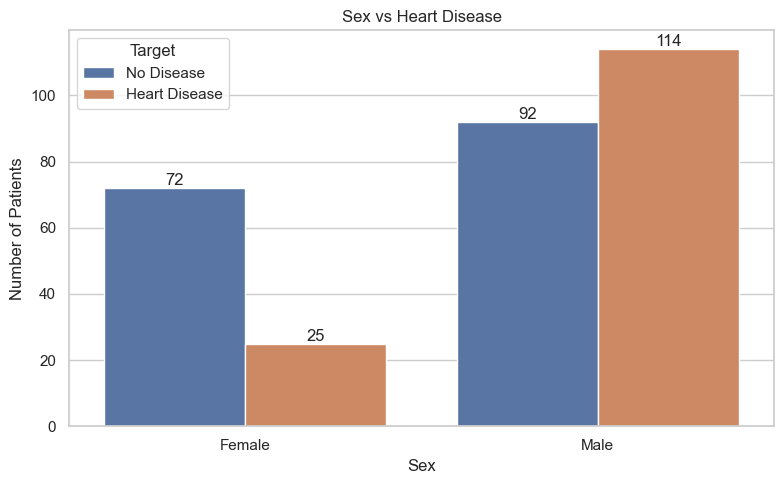

In [166]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="sex",
    hue="target",
    order=sorted(df["sex"].unique())
)

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["Female","Male"])

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("sex_vs_target")
plt.show()

In [167]:
(pd.crosstab(df["sex"], df["target"], normalize="index")*100).round(2)

target,0,1
sex,,
0.0,74.23,25.77
1.0,44.66,55.34


### Insights
- Compare heart disease prevalence between male and female patients.
- Observe whether one gender exhibits a higher proportion of heart disease.
- Evaluate whether sex may contribute to model prediction.

# Chest Pain Type vs Heart Disease
This analysis investigates the relationship between chest pain type and heart disease.
Different chest pain categories may provide valuable diagnostic information regarding cardiovascular conditions.

✓ Saved : cp_vs_target.png


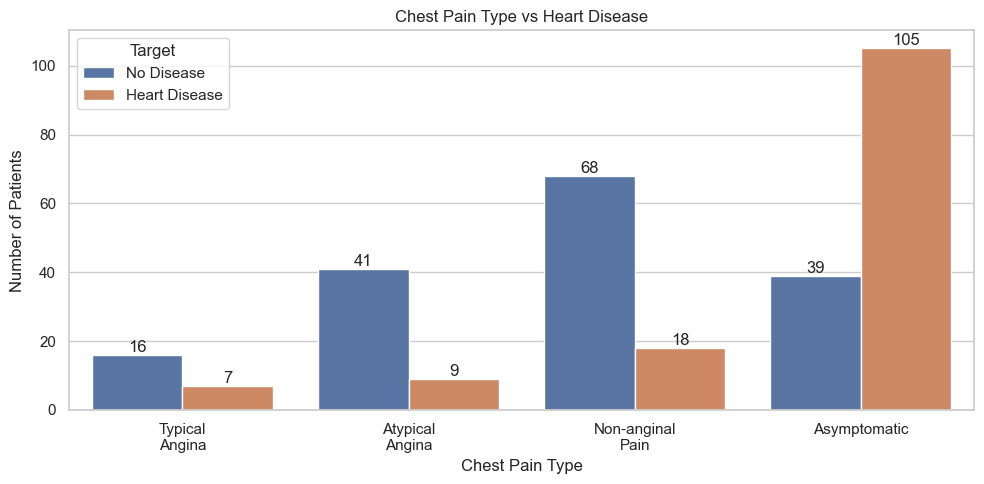

In [168]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="cp",
    hue="target",
    order=sorted(df["cp"].unique())
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2,3],
    labels=[
        "Typical\nAngina",
        "Atypical\nAngina",
        "Non-anginal\nPain",
        "Asymptomatic"
    ]
)

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("cp_vs_target")
plt.show()

In [169]:
(pd.crosstab(df["cp"], df["target"], normalize="index")*100).round(2)

target,0,1
cp,,
1.0,69.57,30.43
2.0,82.00,18.00
3.0,79.07,20.93
4.0,27.08,72.92


### Insights
- Identify which chest pain category has the highest proportion of heart disease.
- Compare disease prevalence across all chest pain types.
- Assess whether chest pain type appears to be a strong predictor.

# Fasting Blood Sugar vs Heart Disease
This section compares fasting blood sugar categories between patients with and without heart disease.

✓ Saved : fbs_vs_target.png


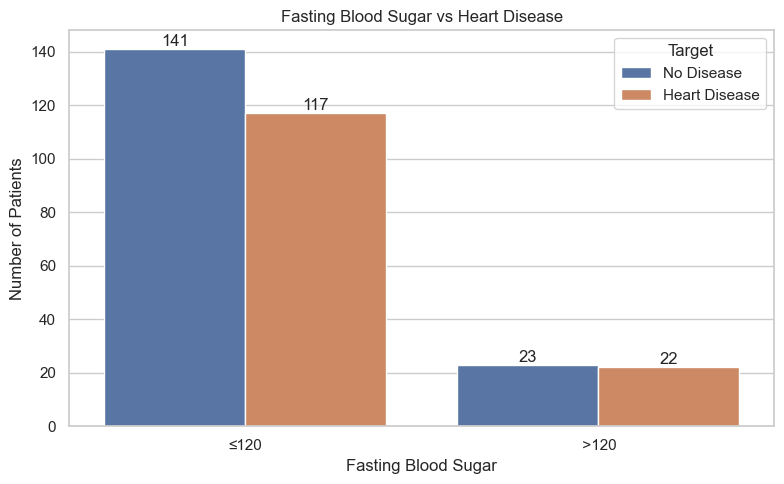

In [170]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="fbs",
    hue="target"
)

plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["≤120"," >120"])
plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("fbs_vs_target")
plt.show()

In [171]:
(pd.crosstab(df["fbs"], df["target"], normalize="index")*100).round(2)

target,0,1
fbs,,
0.0,54.65,45.35
1.0,51.11,48.89


### Insights
- Compare heart disease prevalence between fasting blood sugar categories.
- Observe whether elevated fasting blood sugar is associated with higher disease risk.

# Resting ECG vs Heart Disease
This analysis compares resting electrocardiographic results between patients with and without heart disease.

✓ Saved : restecg_vs_target.png


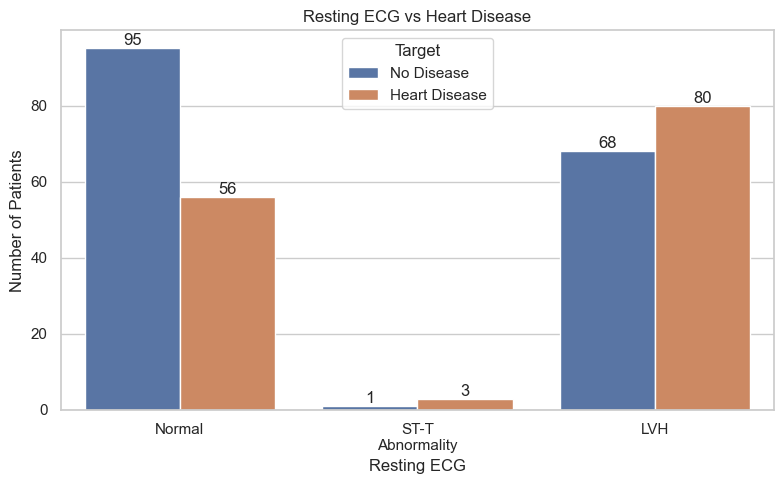

In [172]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="restecg",
    hue="target",
    order=sorted(df["restecg"].unique())
)

plt.title("Resting ECG vs Heart Disease")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2],
    labels=[
        "Normal",
        "ST-T\nAbnormality",
        "LVH"
    ]
)

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("restecg_vs_target")
plt.show()

In [173]:
(pd.crosstab(df["restecg"], df["target"],normalize="index")*100).round(2)

target,0,1
restecg,,
0.0,62.91,37.09
1.0,25.00,75.00
2.0,45.95,54.05


### Insights
- Compare ECG findings between patients with and without heart disease.
- Observe whether abnormal ECG categories contain more heart disease cases.

# Exercise Induced Angina vs Heart Disease
This analysis investigates whether exercise-induced angina is associated with heart disease.
Exercise-induced chest pain is one of the strongest clinical indicators of coronary artery disease.

✓ Saved : exang_vs_target.png


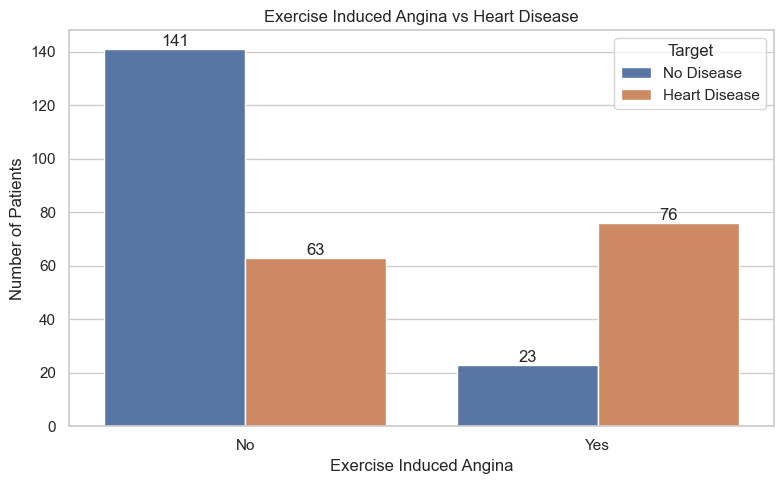

In [174]:
plt.figure(figsize=FIGSIZE)

ax = sns.countplot(
    data=df,
    x="exang",
    hue="target",
    order=sorted(df["exang"].unique())
)

plt.title("Exercise Induced Angina vs Heart Disease")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["No","Yes"])
plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("exang_vs_target")
plt.show()

In [175]:
(pd.crosstab(df["exang"], df["target"], normalize="index")*100).round(2)

target,0,1
exang,,
0.0,69.12,30.88
1.0,23.23,76.77


### Insights
- Compare the prevalence of heart disease between patients with and without exercise-induced angina.
- Assess whether exercise-induced angina appears to be an important predictor.

# ST Slope vs Heart Disease
This section compares the slope of the ST segment during exercise between patients with and without heart disease.

✓ Saved : slope_vs_target.png


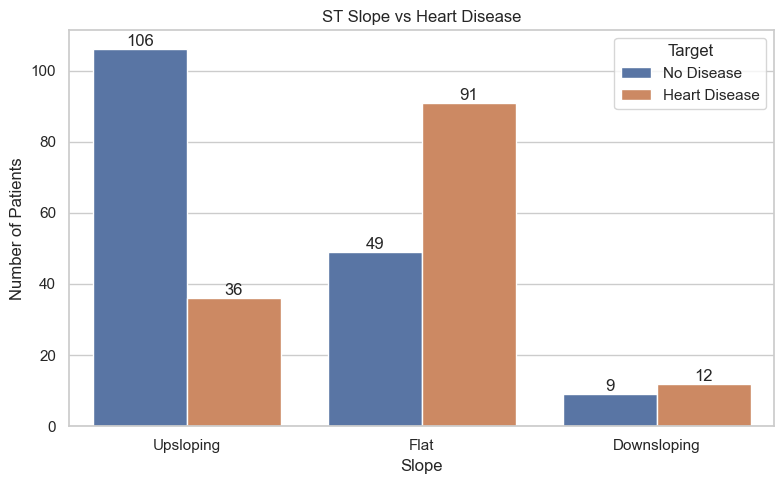

In [176]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="slope",
    hue="target",
    order=sorted(df["slope"].unique())
)

plt.title("ST Slope vs Heart Disease")
plt.xlabel("Slope")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1,2],
    labels=["Upsloping", "Flat", "Downsloping"]
)

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("slope_vs_target")
plt.show()

In [177]:
(pd.crosstab(df["slope"], df["target"], normalize="index")*100).round(2)

target,0,1
slope,,
1.0,74.65,25.35
2.0,35.00,65.00
3.0,42.86,57.14


### Insights
- Compare heart disease prevalence across ST slope categories.
- Observe which ST slope pattern is most frequently associated with heart disease.

# Number of Major Vessels vs Heart Disease
This section compares the number of major coronary vessels observed during fluoroscopy between patients with and without heart disease.

✓ Saved : ca_vs_target.png


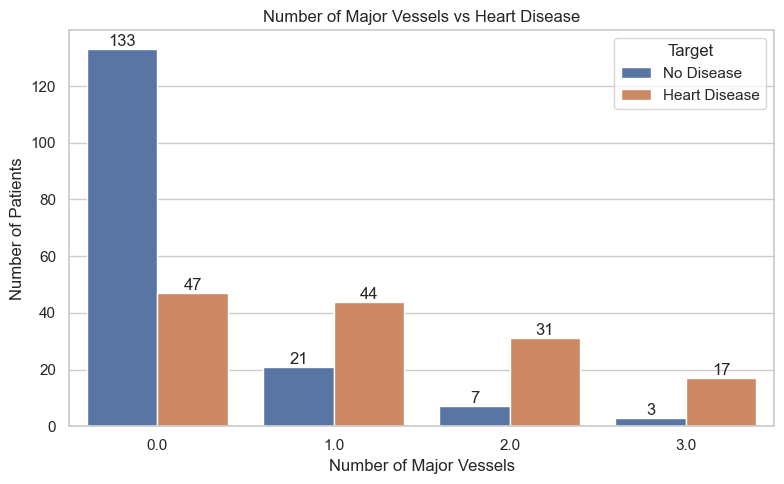

In [178]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="ca",
    hue="target",
    order=sorted(df["ca"].unique())
)

plt.title("Number of Major Vessels vs Heart Disease")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("ca_vs_target")
plt.show()

In [179]:
(pd.crosstab(df["ca"], df["target"], normalize="index")*100).round(2)

target,0,1
ca,,
0.0,73.89,26.11
1.0,32.31,67.69
2.0,18.42,81.58
3.0,15.00,85.00


### Insights
- Compare heart disease prevalence across the number of major vessels.
- Observe whether higher vessel counts correspond to higher disease prevalence.

# Thallium Stress Test vs Heart Disease
This analysis compares Thallium Stress Test results between patients with and without heart disease.
Abnormal perfusion defects detected during the test are commonly associated with coronary artery disease.

✓ Saved : thal_vs_target.png


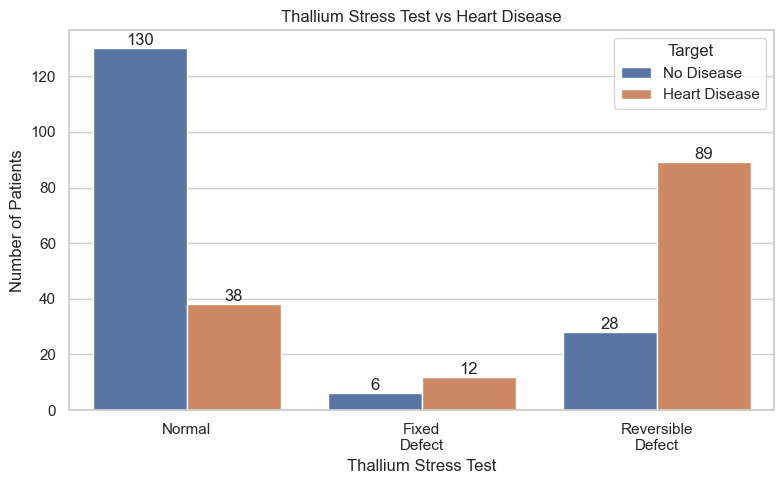

In [180]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="thal",
    hue="target",
    order=sorted(df["thal"].unique())
)

plt.title("Thallium Stress Test vs Heart Disease")
plt.xlabel("Thallium Stress Test")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1,2],
    labels=["Normal", "Fixed\nDefect", "Reversible\nDefect"]
)

plt.legend(
    title="Target",
    labels=["No Disease","Heart Disease"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

save_plot("thal_vs_target")
plt.show()

In [181]:
(pd.crosstab(df["thal"], df["target"], normalize="index")*100).round(2)

target,0,1
thal,,
3.0,77.38,22.62
6.0,33.33,66.67
7.0,23.93,76.07


### Insights
- Compare heart disease prevalence across Thallium Stress Test categories.
- Determine whether abnormal test results are associated with a higher proportion of heart disease.

# Correlation Analysis
Correlation analysis is performed to examine the linear relationship between numerical features.
Although several variables are encoded as integers, the correlation matrix provides a useful overview of potential associations before model development.

✓ Saved : correlation_matrix.png


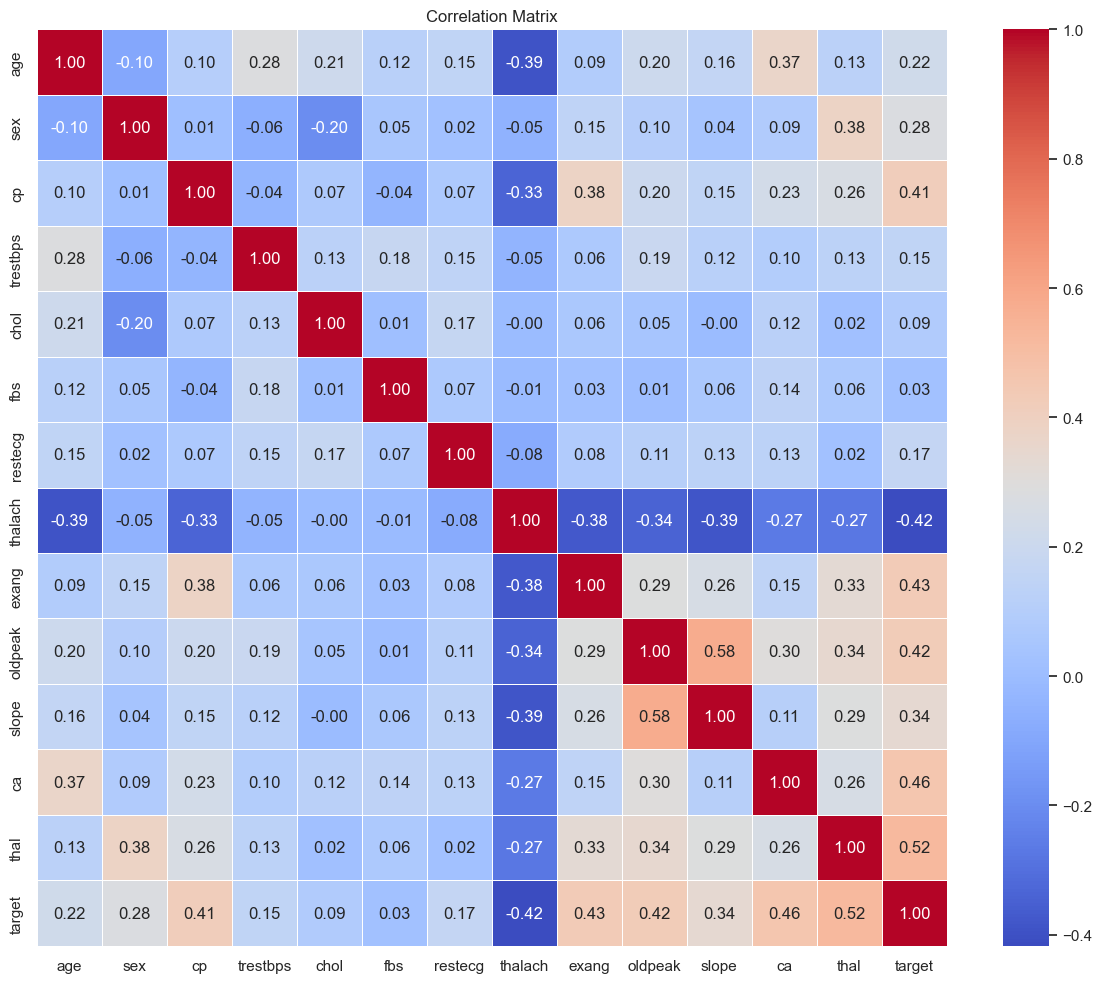

In [182]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
save_plot("correlation_matrix")
plt.show()

### Insights
- Identify variables that exhibit strong positive or negative correlations.
- Observe features with the highest correlation to the target variable.
- Detect potential multicollinearity between predictors.

# Pairwise Relationship Analysis
Pairplots visualize pairwise relationships among selected numerical variables and illustrate how the target classes are distributed across multiple dimensions.

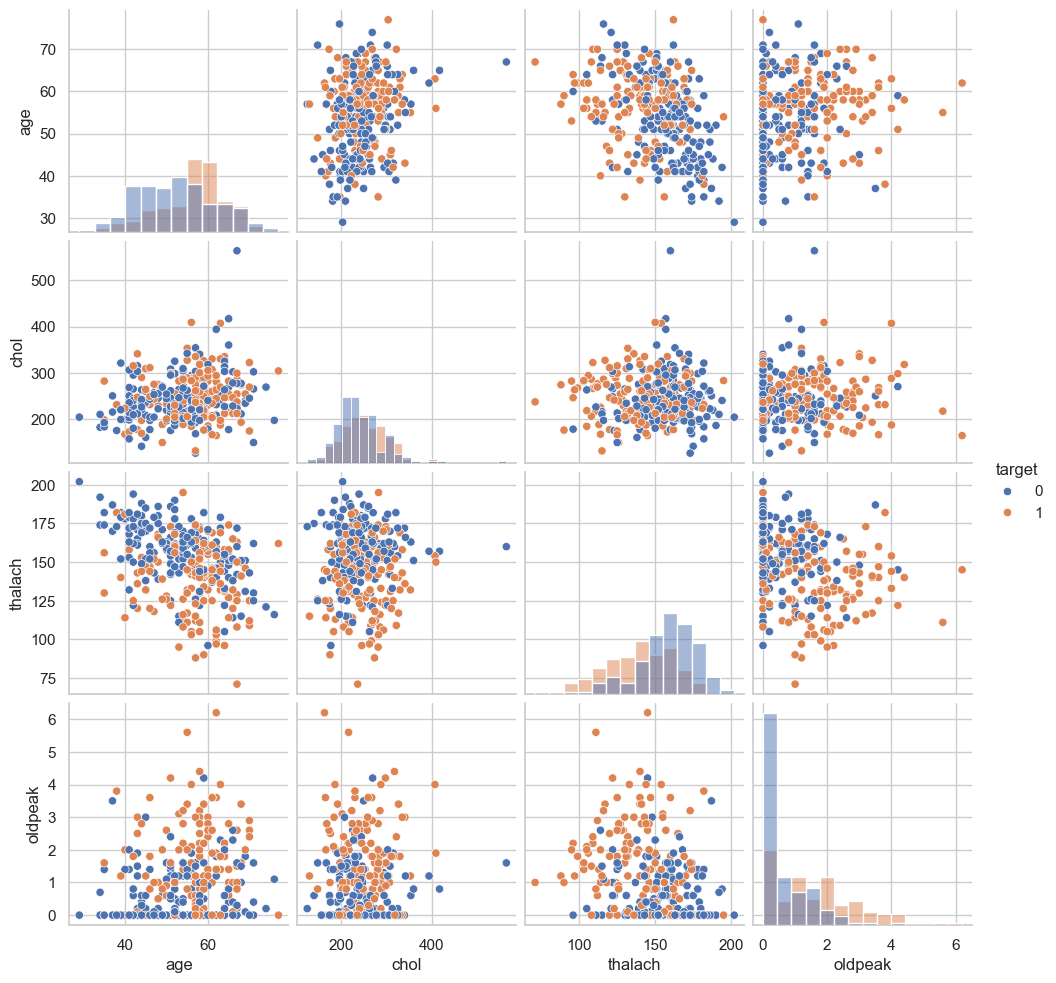

In [183]:
pairplot = sns.pairplot(
    df[["age", "chol", "thalach", "oldpeak", "target"]],
    hue="target",
    diag_kind="hist"
)

pairplot.figure.savefig(
    EDA_IMAGE_DIR/"pairplot.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

# Key Findings
Based on the exploratory data analysis, several important observations were identified:
- The dataset is relatively balanced between patients with and without heart disease.
- Several numerical features show noticeable differences between the two target classes.
- Clinical variables such as chest pain type, exercise-induced angina, number of major vessels, and Thallium Stress Test results appear to be strongly associated with heart disease.
- Some numerical features contain outliers; however, these observations may represent clinically meaningful patient conditions rather than data errors.
- Correlation analysis indicates that certain clinical variables are moderately associated with the target variable, suggesting their potential importance in predictive modeling.

# Conclusion
The exploratory data analysis provides a comprehensive understanding of the dataset and highlights several clinical characteristics associated with heart disease.
The insights obtained from this analysis will guide the next stage of the project, including feature engineering, machine learning model development, model evaluation, and explainability using SHAP.